<div style="background:linear-gradient(to right,#eef2ff,#fef9c3); padding:25px; border-radius:18px; font-family:Arial;">

<h1 style="text-align:center; color:#4c1d95;"> Support Vector Machine (SVM)</h1>

<hr style="height:3px; background:#4c1d95; border:none;">

<h2 style="color:#1d4ed8;"> What is SVM?</h2>

<p style="font-size:16px; color:#111;">
<b style="color:#9333ea;">SVM</b> is a supervised machine learning algorithm used for
<b style="color:#059669;">classification</b> and
<b style="color:#059669;">regression</b>, but mostly famous for <b>classification problems</b>.
</p>

<p style="font-size:16px; color:#111;">
SVM tries to separate the data into different groups by drawing the best possible line or
<b style="color:#dc2626;">hyperplane</b> between classes.
</p>

<p style="font-size:16px; color:#111;">
SVM works best with <b style="color:#2563eb;">non-linear separable data</b>.
</p>

<hr>

<h2 style="color:#1d4ed8;"> How SVM Works</h2>

<ul style="font-size:16px; color:#111;">
<li>It finds the best line/plane that separates data.</li>
<li>Chooses the line with maximum distance from both groups.</li>
<li>This distance is called <b style="color:#dc2626;">Margin</b>.</li>
<li><b style="color:#059669;">More margin = Better model</b></li>
</ul>

<p style="font-size:16px; color:#111;">
SVM doesn't just separate data but finds the best boundary that:
</p>

<ul style="font-size:16px; color:#111;">
<li>Maximizes distance between classes</li>
<li>Reduces error</li>
<li>Works well with complex data</li>
</ul>

<hr>

<h2 style="color:#1d4ed8;"> Benefits of Using SVM</h2>

<ol style="font-size:16px; color:#111;">
<li><b style="color:#9333ea;">Works very well for classification</b>
    <ul>
        <li>Spam detection</li>
        <li>Cancer detection</li>
        <li>Image classification</li>
        <li>Text classification</li>
    </ul>
</li>

<li>Works with small dataset</li>
<li>Handles high dimensional data</li>
<li>Avoids overfitting</li>
<li><b style="color:#dc2626;">Kernel trick (Superpower )</b></li>
</ol>

<p style="font-size:16px; color:#111;">
If data is not separated by a line, SVM converts it into higher dimension and separates it.
</p>

<hr>

<h2 style="color:#1d4ed8;"> Types of Kernels</h2>

<h3 style="color:#7c3aed;">1.  Linear Kernel</h3>
<p>Data is simple and can be separated by straight line. Best for large datasets.</p>

<h3 style="color:#7c3aed;">2. Polynomial Kernel</h3>
<p>Used when data has curved relationship and cannot be separated by straight line.</p>

<h3 style="color:#7c3aed;">3.  RBF (Radial Basis Function)</h3>
<p>
Creates circular or complex boundary. Used when data is very complex and mixed.<br>
Examples: Spam detection, Fraud detection, Face recognition.<br>
<b>Default kernel of SVM.</b>
</p>

<h3 style="color:#7c3aed;">4.  Sigmoid Kernel</h3>
<p>
Used in neural network behaviour. Not commonly used in real


**Importing basic libraries**

In [264]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


**goal of dataset**

predict which drug should be given to a pateint
based on age, sex, bp, chlos, sodium-potassium ratio etc


In [266]:
df = pd.read_csv(r"C:\Users\ajaga\Downloads\svm-classification-ml\drug.csv")

In [267]:
df

,Age,Sex,BP,Cholesterol,Na_to_K,Drug
0,23,F,HIGH,HIGH,25.355,DrugY
1,47,M,LOW,HIGH,13.093,drugC
2,47,M,LOW,HIGH,10.114,drugC
3,28,F,NORMAL,HIGH,7.798,drugX
4,61,F,LOW,HIGH,18.043,DrugY
...,...,...,...,...,...,...
195,56,F,LOW,HIGH,11.567,drugC
196,16,M,LOW,HIGH,12.006,drugC
197,52,M,NORMAL,HIGH,9.894,drugX
198,23,M,NORMAL,NORMAL,14.020,drugX


In [268]:
# eda :

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Age          200 non-null    int64  
 1   Sex          200 non-null    object 
 2   BP           200 non-null    object 
 3   Cholesterol  200 non-null    object 
 4   Na_to_K      200 non-null    float64
 5   Drug         200 non-null    object 
dtypes: float64(1), int64(1), object(4)
memory usage: 9.5+ KB


In [269]:
df.isnull().sum()

Age            0
Sex            0
BP             0
Cholesterol    0
Na_to_K        0
Drug           0
dtype: int64

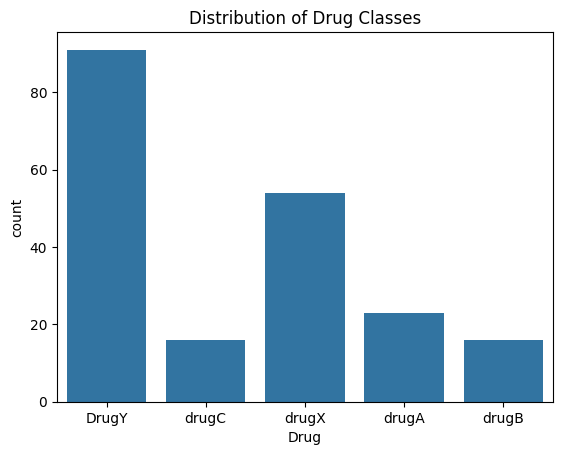

In [270]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='Drug', data=df)
plt.title("Distribution of Drug Classes")
plt.show()

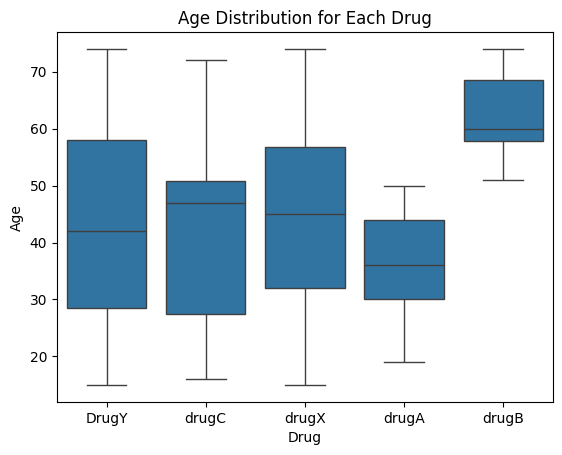

In [271]:
# Age vs Drug
sns.boxplot(x='Drug', y='Age', data=df)
plt.title("Age Distribution for Each Drug")
plt.show()

In [272]:
df.duplicated().sum()

0

In [273]:
# check if target is balanced or imblanced
#df['Drug'].value_counts()


# if any drug > 50 % = imbalanced

df['Drug'].value_counts(normalize=True)*100

Drug
DrugY    45.5
drugX    27.0
drugA    11.5
drugC     8.0
drugB     8.0
Name: proportion, dtype: float64

In [274]:
# does high Natok  always lead to drug y
"""
this table is a contigengy table( relationhip between two variables )
 (also called a crosstab
 ) that explores the relationship between a
  numerical feature and a categorical target."""

pd.crosstab(pd.cut(df['Na_to_K'],bins = 6),df['Drug'])

Drug,DrugY,drugA,drugB,drugC,drugX
Na_to_K,,,,,
"(6.237, 11.599]",0,14,10,11,35
"(11.599, 16.928]",20,9,6,5,19
"(16.928, 22.258]",31,0,0,0,0
"(22.258, 27.588]",22,0,0,0,0
"(27.588, 32.917]",10,0,0,0,0
"(32.917, 38.247]",8,0,0,0,0


In [275]:
df['Drug']

0      DrugY
1      drugC
2      drugC
3      drugX
4      DrugY
       ...  
195    drugC
196    drugC
197    drugX
198    drugX
199    drugX
Name: Drug, Length: 200, dtype: object

In [276]:
df

,Age,Sex,BP,Cholesterol,Na_to_K,Drug
0,23,F,HIGH,HIGH,25.355,DrugY
1,47,M,LOW,HIGH,13.093,drugC
2,47,M,LOW,HIGH,10.114,drugC
3,28,F,NORMAL,HIGH,7.798,drugX
4,61,F,LOW,HIGH,18.043,DrugY
...,...,...,...,...,...,...
195,56,F,LOW,HIGH,11.567,drugC
196,16,M,LOW,HIGH,12.006,drugC
197,52,M,NORMAL,HIGH,9.894,drugX
198,23,M,NORMAL,NORMAL,14.020,drugX


In [277]:
# label encoding :::


from sklearn.preprocessing import LabelEncoder

In [278]:
le = LabelEncoder()
df['Sex'] = le.fit_transform(df['Sex'])
df['BP'] = le.fit_transform(df['BP'])
df['Cholesterol'] = le.fit_transform(df['Cholesterol'])
df['Drug'] = le.fit_transform(df['Drug'])

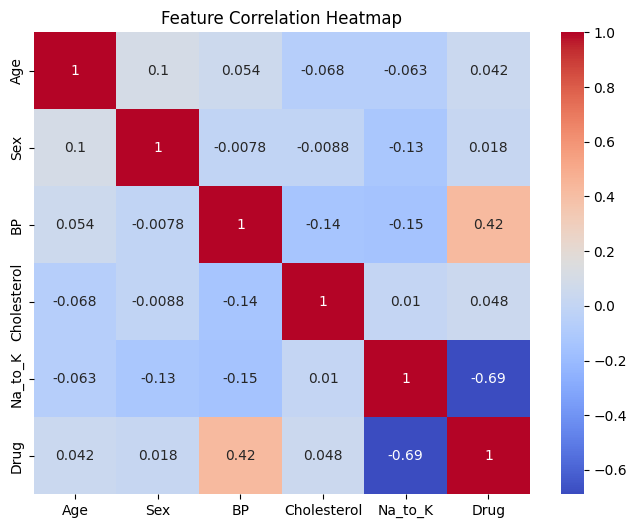

In [279]:
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.title("Feature Correlation Heatmap")
plt.show()

In [280]:
for i in df.columns:
  if df[i].dtypes =='object':
    df[i] = le.fit_transform(df[i])

In [281]:
df

,Age,Sex,BP,Cholesterol,Na_to_K,Drug
0,23,0,0,0,25.355,0
1,47,1,1,0,13.093,3
2,47,1,1,0,10.114,3
3,28,0,2,0,7.798,4
4,61,0,1,0,18.043,0
...,...,...,...,...,...,...
195,56,0,1,0,11.567,3
196,16,1,1,0,12.006,3
197,52,1,2,0,9.894,4
198,23,1,2,1,14.020,4


In [282]:
x = df.drop('Drug', axis = 1)

In [283]:
y = df['Drug']

In [284]:
x

,Age,Sex,BP,Cholesterol,Na_to_K
0,23,0,0,0,25.355
1,47,1,1,0,13.093
2,47,1,1,0,10.114
3,28,0,2,0,7.798
4,61,0,1,0,18.043
...,...,...,...,...,...
195,56,0,1,0,11.567
196,16,1,1,0,12.006
197,52,1,2,0,9.894
198,23,1,2,1,14.020


In [285]:
y

0      0
1      3
2      3
3      4
4      0
      ..
195    3
196    3
197    4
198    4
199    4
Name: Drug, Length: 200, dtype: int32

In [286]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
x = scaler.fit_transform(x)

In [287]:
from sklearn.model_selection import train_test_split

In [288]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state = 0)

In [289]:
# svc : support vector classifer

from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

kernels = ['linear','rbf','poly','sigmoid']

for k in kernels:
    model = SVC(kernel=k)
    model.fit(x_train, y_train)
    
    pred = model.predict(x_test)
    acc = accuracy_score(y_test, pred)
    
    print("Kernel:",k," Accuracy:",acc)

Kernel: linear  Accuracy: 0.95
Kernel: rbf  Accuracy: 0.975
Kernel: poly  Accuracy: 0.85
Kernel: sigmoid  Accuracy: 0.95


In [290]:
model1 = SVC()

# default : rbf

In [291]:
model1.fit(x_train,  y_train)

SVC()

In [292]:
y_pred =model1.predict(x_test)

In [293]:
y_pred

array([3, 4, 0, 0, 0, 4, 4, 4, 0, 4, 1, 0, 0, 0, 2, 3, 0, 0, 4, 0, 0, 4,
       4, 4, 0, 0, 4, 0, 0, 4, 4, 3, 1, 4, 0, 0, 4, 0, 1, 4])

In [294]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
print(cm)

[[18  0  0  0  1]
 [ 0  3  0  0  0]
 [ 0  0  1  0  0]
 [ 0  0  0  3  0]
 [ 0  0  0  0 14]]


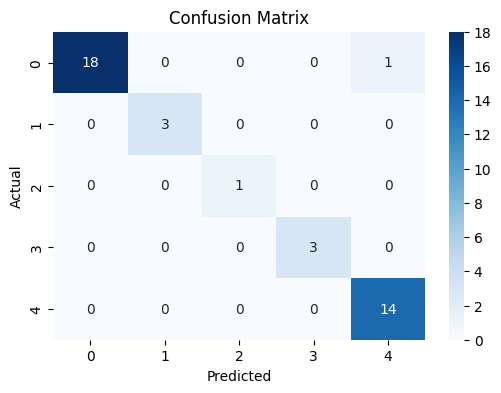

In [295]:
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [296]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      0.95      0.97        19
           1       1.00      1.00      1.00         3
           2       1.00      1.00      1.00         1
           3       1.00      1.00      1.00         3
           4       0.93      1.00      0.97        14

    accuracy                           0.97        40
   macro avg       0.99      0.99      0.99        40
weighted avg       0.98      0.97      0.98        40



In [297]:
from sklearn.metrics import accuracy_score

In [298]:
print(f" accuracy score svd {accuracy_score(y_pred, y_test)*100}")

 accuracy score svd 97.5


In [299]:
# linear kernel :::

model2 = SVC(kernel = 'linear')
model2.fit(x_train  , y_train)
y2_pred =model2.predict(x_test )


print(f" accuracy score svd {accuracy_score(y2_pred, y_test)*100}")


# 100% : overfitt ::::

 accuracy score svd 95.0


In [300]:
# poly kernel :::

model3 = SVC(kernel = 'poly')
model3.fit(x_train  , y_train)
y3_pred =model3.predict(x_test )


print(f" accuracy score svd {accuracy_score(y3_pred, y_test)*100}")


# 100% : overfitt ::::

 accuracy score svd 85.0


In [301]:
# sigmoid kernel :::
model4 = SVC(kernel = 'sigmoid')
model4.fit(x_train  , y_train)
y4_pred =model4.predict(x_test )


print(f" accuracy score svd {accuracy_score(y4_pred, y_test)*100}")

#

 accuracy score svd 95.0


In [302]:
# Example prediction

sample = [[47,1,1,1,14.5]]   # Example patient data

sample = scaler.transform(sample)

prediction = model1.predict(sample)

print("Predicted Drug:", prediction)


Predicted Drug: [4]


C:\Users\ajaga\AppData\Roaming\Python\Python312\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


Conclusion

In this project, Support Vector Machine (SVM) was used to classify which drug should be prescribed based on patient attributes such as age, sex, blood pressure, cholesterol level, and Na_to_K ratio.

The dataset was preprocessed by encoding categorical variables and scaling features. Different SVM kernels were tested and the model performance was evaluated using accuracy, confusion matrix, and classification report.

The model successfully predicts the appropriate drug class with good accuracy.